In [2]:
##Importing necessary packages
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
from SSINS import INS
import os
from scipy.signal.windows import dpss
from custom_funcs import chan_avg, chan_select


(10, 903)


/var/folders/m_/qdkhzz6n1j3_fjt6_pj6ycv40000gn/T/ipykernel_50866/3634245257.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  samples[n, i] = st.gennorm.rvs(*params[i, :], size=1)


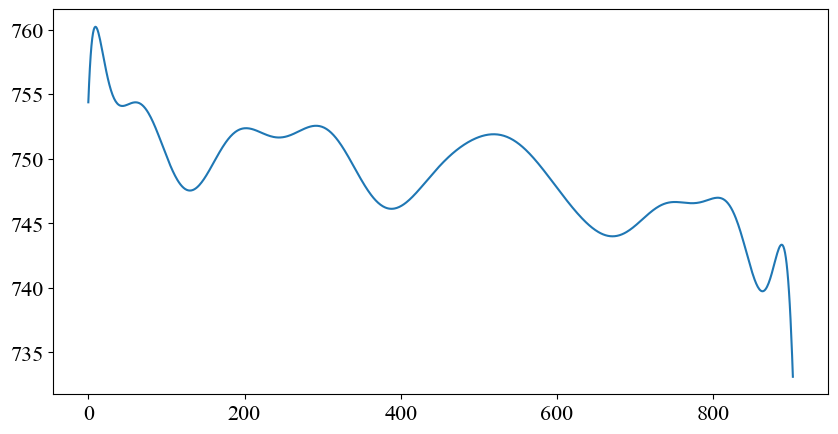

In [3]:

##Setting font size
plt.rcParams.update({'font.size': 16,
                     'font.family': 'serif',
                     'font.serif': 'Times New Roman'})

n_iters = 10
N_terms = 25
length = 903

samples = np.zeros(shape=(n_iters, N_terms))

params = np.load('../data/coeff_params_gnorm.npy')

tapers = np.empty(shape=(length,))

for n in range(n_iters):

    for i in range(0, 25):
        samples[n, i] = st.gennorm.rvs(*params[i, :], size=1)

    coeff = samples[0, :]
    NW, K = 4, N_terms-1
    basis = dpss(length, NW, K)
    design = np.concatenate(([np.ones(shape=(length,))], basis)).T
    Q = np.linalg.qr(design, mode='reduced')[0]
    background = Q @ coeff

    tapers = np.vstack((tapers, background))

tapers = tapers[1:, :]
print(tapers.shape)

plt.figure(figsize=(10, 5))
plt.plot(tapers[0, :])


##To do: cut out the null zones, inject emissions, do the DPSS reverse problem.

In [4]:
##Importing data file from Data folder

#Defining the data directory and night in file name
data_dir = "../data"
night = "109078_p1"

#Constructing datapath and constructing ins object using SSINS
datapath = os.path.join(data_dir, night + "_SSINS_data.h5")
maskpath = os.path.join(data_dir, night + "_SSINS_mask.h5")
ins = INS(datapath, telescope_name='MWA', mask_file=maskpath)


#Defining shape dictionary
TV_dict = {
    'TV6': [1.74e8, 1.81e8],
    'TV7': [1.81e8, 1.88e8],
    'TV8': [1.88e8, 1.95e8],
    'TV9': [1.95e8, 2.02e8]
    }

#Selecting one DTV subband
chan_name = 'TV7'

#Extracting and averaging over the selected subband
ins_subband, masked_ins, N_bl, N_freq = chan_select(ins, chan_name, TV_dict)
time, amp = chan_avg(ins_subband)
masked_time, masked_amp = chan_avg(masked_ins)

invalid value encountered in multiply
invalid value encountered in divide
sig_array has been reset


invalid value encountered in sqrt


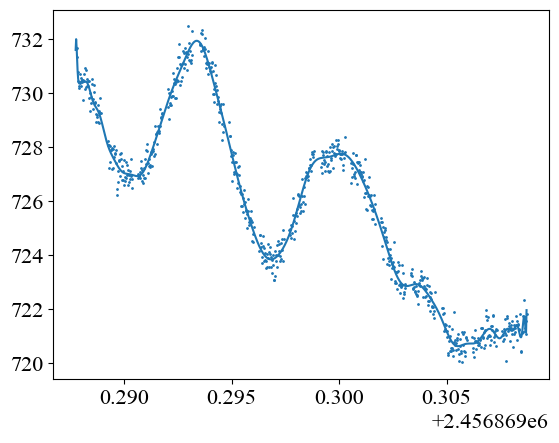

invalid value encountered in sqrt


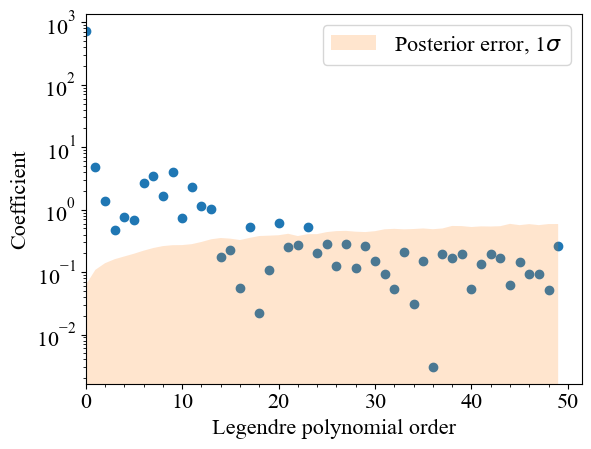

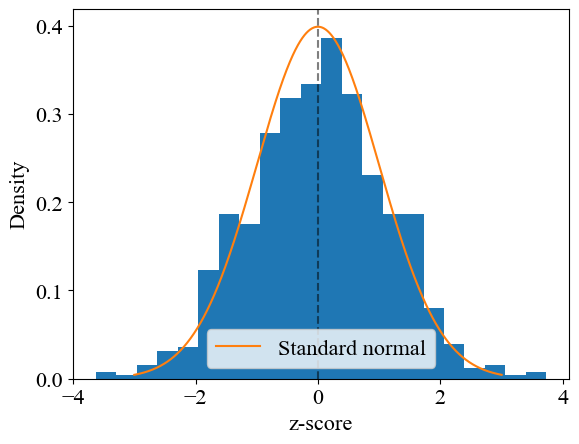

In [9]:
from scipy.special import legendre

N_terms = 50

dt = st.mode(np.diff(time)).mode
smooth_time = np.arange(time.min(), time.max() + dt, dt)
padded_amp = np.full_like(smooth_time, np.nan, dtype=float)
indices = np.searchsorted(smooth_time, time)
padded_amp[indices] = amp

timeline = np.linspace(-1, 1, smooth_time.shape[0])

design = np.zeros(shape=(smooth_time.shape[0], N_terms))

for i in range(0, N_terms):
    design[:, i] = legendre(n=i)(timeline)

splice_design = design[indices, :]

coeffs = np.linalg.solve(splice_design.T @ splice_design, splice_design.T @ amp)
fit = design @ coeffs


#Finding the noise covariance
mu = splice_design @ coeffs
C = 4/np.pi-1
noise_cov = np.diag((fit ** 2) * C / (N_bl * N_freq))
splice_noise_cov = np.diag((mu ** 2) * C / (N_bl * N_freq))

#Finding the parameter covariance
sigma_p = np.linalg.solve(splice_design.T @ np.linalg.solve(splice_noise_cov, splice_design), np.eye(splice_design.shape[1]))

#Finding the fit covariance
sigma_f = design @ sigma_p @ design.T
noise_err = np.diag(np.sqrt(noise_cov))
fit_err = np.diag(np.sqrt(sigma_f))



plt.scatter(smooth_time, padded_amp, s=1)
plt.plot(smooth_time, fit)
plt.show()

plt.scatter(np.arange(0, coeffs.shape[0]), np.abs(coeffs))
plt.minorticks_on()
plt.fill_between(np.arange(0, coeffs.shape[0]), 0, 5*np.diag(np.sqrt(sigma_p)), alpha=0.2, label=r'Posterior error, 1$\sigma$')
plt.yscale('log')
plt.xlim(0)
plt.xlabel("Legendre polynomial order")
plt.ylabel("Coefficient")
plt.legend()
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.show()

x = np.linspace(-3, 3, 1000)
plt.hist((padded_amp-fit)/noise_err, bins='auto', density=True)
plt.plot(x, np.exp(-x**2/2)/np.sqrt(2*np.pi), label='Standard normal')
plt.axvline(x=0, color='k', alpha=0.5, linestyle='--')
plt.legend()
plt.xlabel('z-score')
plt.ylabel('Density')
plt.yscale('linear')